Inspired by: https://qiskit-community.github.io/qiskit-finance/tutorials/00_amplitude_estimation.html


https://github.com/qiskit-community/qiskit-algorithms/blob/main/qiskit_algorithms/amplitude_estimators/iae.py

# Quantum Amplitude Estimation
There are many different variations of the original QAE algorithm but they all have the same goal, to use random sampling to estimate quantum amplitudes and probabilites. The classical version is Monte Carlo Simulation.
It has applications in finance option pricing, integration, and anything else that uses random sampling.

The problem goes like this, lets assume we are given an operator A, we then apply it to a quantum system and want to measure how it changes the ampltidues.

We start by applying A to our qubit to change it into the $\lvert{\psi}\rangle$ state.
$$A\lvert{0}\rangle = \lvert{\psi}\rangle$$
We then mark the "success" or the state we want to measure the amplitude of.
$$\lvert{\psi}\rangle = \sqrt{1-p}\lvert{\psi_\text{bad}}\rangle + \sqrt{p}\lvert{\psi_{\text{good}}}\rangle$$

or more formally

$$A\lvert{\Psi_0}\rangle\lvert0\rangle = \sqrt{1-a}\lvert{\Psi_0}\rangle\lvert0\rangle + \sqrt{a}\lvert{\Psi_1}\rangle\lvert1\rangle$$


$p_k = \sin^2\left((2k+1)\theta\right), \quad \theta = \arcsin\left(\sqrt{a}\right)$

The classical way to compute this using monte carlo simulation. This has an error rate with scaling of $\frac{1}{\sqrt{M}}$. Thankfully there is also a way to compute this quantumaly. When we do this, we are able to compute this with a error rate scaling of $\frac{1}{M}$. For this explanation we will use a version of QAE called Iterative Quantum Amplitdue Estimation (IQAE).

## QAE Applications
QAE algorihtms have been shown to be able to achieve expontential speed up over classical computing Monte Carlo simulations. This is useful for the areas of high dimensional integration, finance model derivations, and quantum physics.

https://www.mdpi.com/2624-960X/6/1/1
## QAE Example Runthrough

As mentioned above, one application of QAE algorithms is that they provide a speedup in the approximation of complete integrals. Lets go through how this is the case.
Given an integral:
$$ I = \int f(x) dx $$
we can rewrite it as:
$$I = \int p(x)\, g(x)\, dx = \mathbb{E}_p[g(x)]$$
where $p(x)$ is a probability distribution and $g(x)$ is $\frac{f(x)}{p(x)}$. $\mathbb{E}_p[g(x)]$ is the expectation operator of $g(x)$, it can be though of as the average value of $g(x)$ given we are sampling over a distribution $p(x)$. The integral over $f(x)$ can be estimated by collecting the expecation values of integrating over different probility distributions.

Given our formula for QAE defined above:
$$A\lvert{\Psi_0}\rangle\lvert0\rangle = \sqrt{1-a}\lvert{\Psi_0}\rangle\lvert0\rangle + \sqrt{a}\lvert{\Psi_1}\rangle\lvert1\rangle$$
we can think of $\lvert{\Psi_1}\rangle$ as being the "good" state we are trying to measure and in the context of integration approximation this means

$$
\lvert\Psi_1\rangle =
\frac{1}{\sqrt{a}} \sum_x \sqrt{p(x)g(x)} \, |x\rangle_n
$$

The original QAE then procedes by defining an Oracle then applying it $M$ times where $M = 2^m$ where $m$ is the number of ancilla qubits. It then applied the inverse Quantum Fourier Transform to the ancilla qubits and the result obtained from the measurement is $y \in \{0, \ldots, M-1\}$ and the estimation of $a$ is $\tilde{a} = \sin^2(\theta_a)$ where $\theta_a \equiv\frac{y\pi}{M}$ with error scaling at $ \sim \frac{1}{M}$.


One drawback of the original QAE algorithm is that it requires the use of the Quantum Fourier Transform (QFT) and multiple ancilla qubits. Iterative Quantum Amplitude Estimation (IQAE) removes them and instead uses a classical iterative subroutine that repeatedly refines an estimate of the amplitude.

As in standard QAE, we begin with the state
$$A|\Psi_0\rangle|0\rangle = \sqrt{1-a}|\Psi_0\rangle|0\rangle
+ \sqrt{a}|\Psi_1\rangle|1\rangle$$

where the goal is to estimate the amplitude $a$, corresponding to the probability of measuring the “good” state $|1\rangle$.

Instead of performing phase estimation, IQAE repeatedly applies powers of the Grover operator $Q$ and measures the resulting probability of observing the good state. After applying $Q^k$, the probability of measuring $|1\rangle$ in the final qubit is

$$P(|1\rangle) = \sin^2((2k+1)\theta_a) $$
where the amplitude $a$ is related to the angle $\theta_a$ by $a = \sin^2(\theta_a)$

To estimate this probability, the circuit

$$Q^k A |0\rangle_n |0\rangle$$

is executed multiple times and the frequency of measuring $|1\rangle$ is recorded.

The algorithm uses a confidence interval $[\theta_l, \theta_u]$ that contains the true value of $\theta_a$.

At each iteration, a classical routine chooses an integer $k$ that maximizes the information obtained from the measurement while ensuring that the transformed interval $[(4k+2)\theta_l,(4k+2)\theta_u] \bmod 2\pi$ lies entirely within either $[0,\pi] \text{ or } [\pi,2\pi]$.

This constraint ensures that the function $\cos((4k+2)\theta_a)$ can be uniquely inverted, allowing the algorithm to shrink the confidence interval for $\theta_a$.

By repeating this process iteratively, the interval containing $\theta_a$ becomes progressively smaller until the desired accuracy $\epsilon$ is reached. The final estimate of the amplitude is then obtained from $\tilde{a} = \sin^2(\theta_a)$.

Unlike the original QAE algorithm, IQAE does not require the QFT or large ancilla registers. Instead, it relies on repeated circuit executions and classical post-processing to refine the estimate while still achieving the quadratic speedup over classical Monte Carlo methods.

In [ ]:
# @title Initial Imports
!pip install -q qiskit
!pip install -q qiskit_algorithms
!pip install -q qiskit_aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 59.1 MB/s eta 0:00:00


Below the intervals are shown for different amounts of Grover Oracle calls, the green lines plot a $\frac{1}{M}$ relationship and we can see that the bounds of the confidence intervals are approaching the green lines.

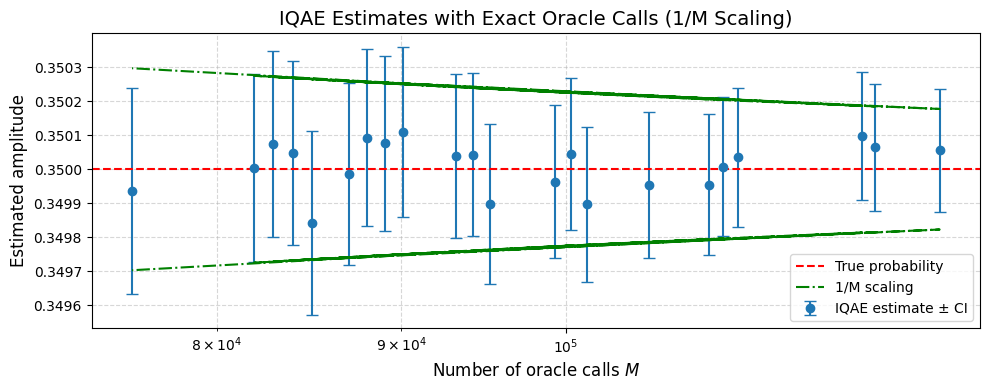

In [ ]:
# @title QAE Error Plot
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_algorithms import IterativeAmplitudeEstimation, EstimationProblem
from qiskit_aer.primitives import SamplerV2

# -----------------------------
# Bernoulli operator setup
# -----------------------------
p_true = 0.35

class BernoulliA(QuantumCircuit):
    def __init__(self, probability):
        super().__init__(1)
        theta_p = 2 * np.arcsin(np.sqrt(probability))
        self.ry(theta_p, 0)

class BernoulliQ(QuantumCircuit):
    def __init__(self, probability):
        super().__init__(1)
        self._theta_p = 2 * np.arcsin(np.sqrt(probability))
        self.ry(2 * self._theta_p, 0)
    def power(self, k):
        qc = QuantumCircuit(1)
        qc.ry(2 * k * self._theta_p, 0)
        qc.metadata = {"k": k}  # store k for oracle count tracking
        return qc


# -----------------------------
# Prepare IQAE problem
# -----------------------------
A = BernoulliA(p_true)
Q = BernoulliQ(p_true)

problem = EstimationProblem(
    state_preparation=A,
    grover_operator=Q,
    objective_qubits=[0]
)

sampler = SamplerV2()

# -----------------------------
# Run IQAE for multiple epsilons
# -----------------------------
# Desired range of oracle calls
min_calls = 500
max_calls = 1000
num_points = 50

# Generate oracle calls evenly in linear space
target_oracle_calls = np.linspace(min_calls, max_calls, num_points)

# Convert back to epsilon values (roughly ε ~ 1 / M)
epsilon_list = 1 / target_oracle_calls
#epsilon_list = np.logspace(-1, -3.3, 400)
estimates = []
ci_lowers = []
ci_uppers = []
oracle_calls = []

for eps in epsilon_list:

    iae = IterativeAmplitudeEstimation(
        epsilon_target=eps,
        alpha=0.05,
        sampler=sampler
    )
    result = iae.estimate(problem)
    if (result.num_oracle_queries in oracle_calls):
        continue  # skip if this oracle call count has already been recorded

    estimates.append(result.estimation)
    ci_lowers.append(result.confidence_interval[0])
    ci_uppers.append(result.confidence_interval[1])
    oracle_calls.append(result.num_oracle_queries)  # exact oracle calls

# Prepare data to be plotted

estimates = np.array(estimates)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)
errors = np.stack([estimates - ci_lowers, ci_uppers - estimates])
oracle_calls = np.array(oracle_calls)

# Compute absolute errors from true probability
errors = np.stack([estimates - ci_lowers, ci_uppers - estimates])

# Remove entries with 0 oracle calls
nonzero_mask = oracle_calls > 0
oracle_calls_nonzero = oracle_calls[nonzero_mask]
errors_nonzero = errors[:, nonzero_mask]
estimates_nonzero = estimates[nonzero_mask]


# Reference 1/M line

# Scale the line to match the first nonzero error
scale_factor = errors_nonzero[1,0]  # upper CI width
iqae_ref = scale_factor * oracle_calls_nonzero[0] / oracle_calls_nonzero


# Plot

plt.figure(figsize=(10,4))

# IQAE estimates with CI
plt.errorbar(
    x=oracle_calls_nonzero,
    y=estimates_nonzero,
    yerr=errors_nonzero,
    fmt='o',
    capsize=4,
    label='IQAE estimate ± CI'
)

# True probability
plt.axhline(p_true, color='r', linestyle='--', label='True probability')

# Ideal IQAE 1/M reference
plt.plot(oracle_calls_nonzero, p_true + iqae_ref, 'g-.', label='1/M scaling')
plt.plot(oracle_calls_nonzero, p_true - iqae_ref, 'g-.')

plt.xscale('log')
plt.yscale('linear')
plt.xlabel('Number of oracle calls $M$', fontsize=12)
plt.ylabel('Estimated amplitude', fontsize=12)
plt.title('IQAE Estimates with Exact Oracle Calls (1/M Scaling)', fontsize=14)
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

IQAE is $ \text{error} \sim \frac{1}{M}$ so $M \sim \frac{1}{\varepsilon}\quad\text{(oracle calls)} $
This shows that the confidence intervals are becoming bounded by the error

# Other Code

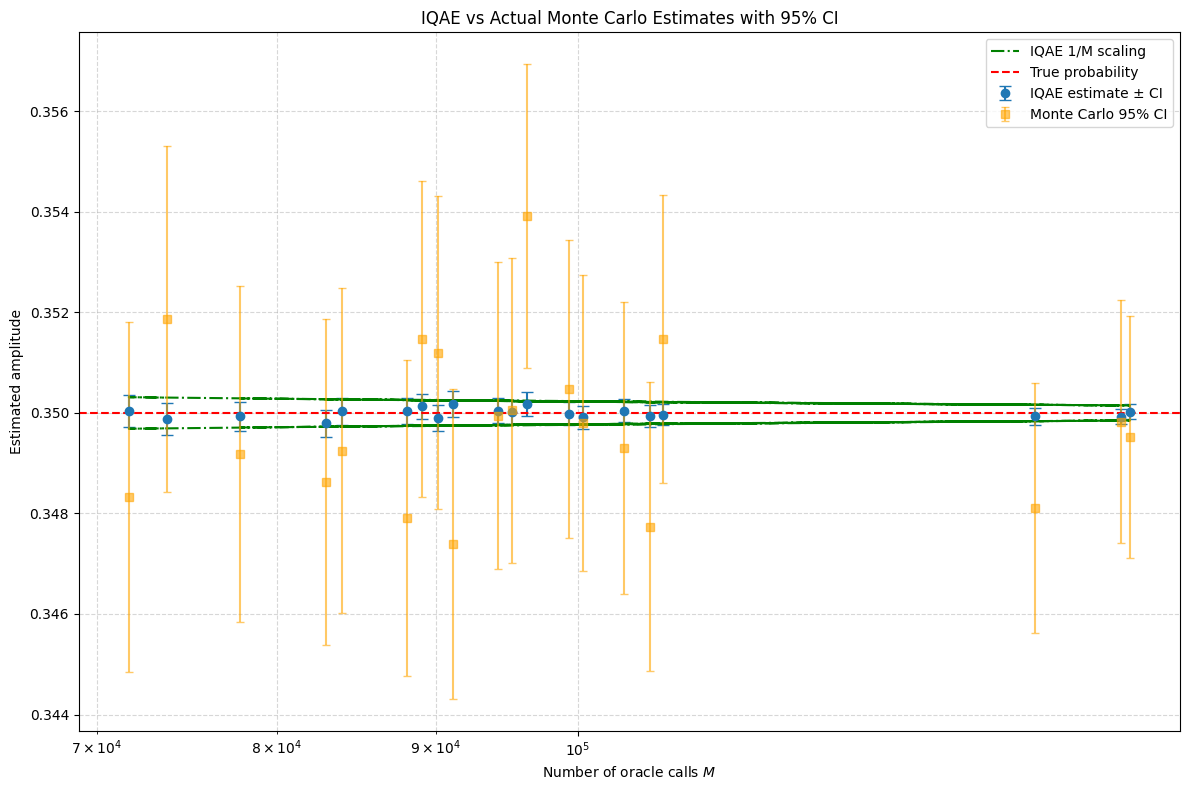

In [ ]:
import numpy as np
import matplotlib.pyplot as plt



# Monte Carlo simulation

np.random.seed(42)

M_mc = oracle_calls_nonzero.astype(int)
mc_estimates = []
mc_ci_lower = []
mc_ci_upper = []

for M in M_mc:
    samples = np.random.binomial(1, p_true, M)   # simulate M Bernoulli trials
    mean_est = samples.mean()
    std_err = np.sqrt(mean_est * (1 - mean_est) / M)
    mc_estimates.append(mean_est)
    mc_ci_lower.append(mean_est - 1.96*std_err)
    mc_ci_upper.append(mean_est + 1.96*std_err)

mc_estimates = np.array(mc_estimates)
mc_ci_lower = np.array(mc_ci_lower)
mc_ci_upper = np.array(mc_ci_upper)
mc_errors = np.stack([mc_estimates - mc_ci_lower, mc_ci_upper - mc_estimates])

# -----------------------------
# Plot IQAE vs Monte Carlo
# -----------------------------
plt.figure(figsize=(12,8))

# IQAE estimates with CI
plt.errorbar(
    x=oracle_calls_nonzero,
    y=estimates_nonzero,
    yerr=errors_nonzero,
    fmt='o',
    capsize=4,
    label='IQAE estimate ± CI'
)

# IQAE ideal 1/M reference
plt.plot(oracle_calls_nonzero, p_true + iqae_ref, 'g-.', label='IQAE 1/M scaling')
plt.plot(oracle_calls_nonzero, p_true - iqae_ref, 'g-.')

# Monte Carlo estimates with CI
plt.errorbar(
    M_mc,
    mc_estimates,
    yerr=mc_errors,
    fmt='s',
    capsize=3,
    label='Monte Carlo 95% CI',
    color='orange',
    alpha=0.6
)

# True probability line
plt.axhline(p_true, color='r', linestyle='--', label='True probability')

plt.xscale('log')
plt.xlabel('Number of oracle calls $M$')
plt.ylabel('Estimated amplitude')
plt.title('IQAE vs Actual Monte Carlo Estimates with 95% CI')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

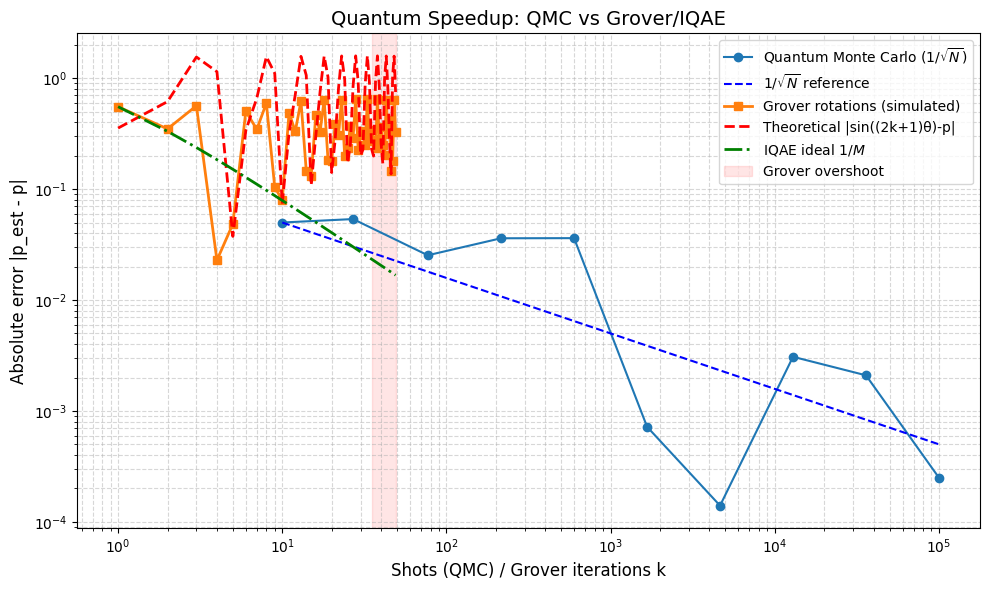

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# -----------------------------
# Parameters
# -----------------------------
p = 0.35
theta = np.arcsin(np.sqrt(p))
K_list = np.arange(1, 50)             # Grover iterations
shots_mc_list = np.logspace(1, 5, 10, dtype=int)  # Monte Carlo shots
shots_per_grover = 1024               # shots per Grover step

backend = AerSimulator()

# -----------------------------
# Monte Carlo simulation (QMC)
# -----------------------------
qmc_errors = []
for N in shots_mc_list:
    qc = QuantumCircuit(1, 1)
    qc.ry(2*theta, 0)          # state prep
    qc.measure(0, 0)

    result = backend.run(qc, shots=N).result()
    counts = result.get_counts()
    p_est = counts.get('1',0)/N
    qmc_errors.append(abs(p_est - p))

qmc_errors = np.array(qmc_errors)

# -----------------------------
# Grover rotations simulation
# -----------------------------
grover_errors = []
for k in K_list:
    qc = QuantumCircuit(1, 1)
    qc.ry(2*theta, 0)                # state prep
    qc.ry(2*k*2*theta, 0)            # k Grover rotations
    qc.measure(0, 0)

    result = backend.run(qc, shots=shots_per_grover).result()
    counts = result.get_counts()
    p_est = counts.get('1',0)/shots_per_grover
    grover_errors.append(abs(p_est - p))

grover_errors = np.array(grover_errors)

# -----------------------------
# Theoretical curves
# -----------------------------
# QMC reference: 1/sqrt(N)
qmc_ref = qmc_errors[0]*np.sqrt(shots_mc_list[0])/np.sqrt(shots_mc_list)

# Grover theoretical error: |sin((2k+1)θ) - p|
a_theory = np.sin((2*K_list + 1)*theta)
grover_ref = np.abs(a_theory - np.sqrt(p))

# IQAE ideal 1/M reference
# Total oracle calls for k Grover rotations with shots_per_grover each:
M_grover = (2*K_list + 1) * shots_per_grover
iqae_ref = grover_errors[0] * M_grover[0] / M_grover  # scale first point to match

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10,6))

# Monte Carlo
plt.loglog(shots_mc_list, qmc_errors, 'o-', color='tab:blue', markersize=6, label=r'Quantum Monte Carlo (1/$\sqrt{N}$)')
plt.loglog(shots_mc_list, qmc_ref, 'b--', label=r'$1/\sqrt{N}$ reference')

# Grover simulation
plt.loglog(K_list, grover_errors, 's-', color='tab:orange', markersize=6, linewidth=2, label=r'Grover rotations (simulated)')
plt.loglog(K_list, grover_ref, 'r--', linewidth=2, label=r'Theoretical |sin((2k+1)θ)-p|')

# IQAE 1/M reference
plt.loglog(K_list, iqae_ref, 'g-.', linewidth=2, label=r'IQAE ideal $1/M$')

# Highlight overshoot region
plt.axvspan(35, max(K_list), color='red', alpha=0.1, label='Grover overshoot')

plt.xlabel('Shots (QMC) / Grover iterations k', fontsize=12)
plt.ylabel('Absolute error |p_est - p|', fontsize=12)
plt.title('Quantum Speedup: QMC vs Grover/IQAE', fontsize=14)
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Below here is code I tried implementing from the paper's algorithm. It looks almost right but I cant figure out how to make it run enough oracle calls to plot it to show the $ \frac{1}{M}$ relationship

  i |   k |   p_meas | Theta Interval
--------------------------------------------------
  1 |   0 |   0.0075 | [0.0677, 0.1113]
  2 |  13 |   0.1800 | [0.0736, 0.0752]

Estimated a: 0.005528
True a:      0.009967


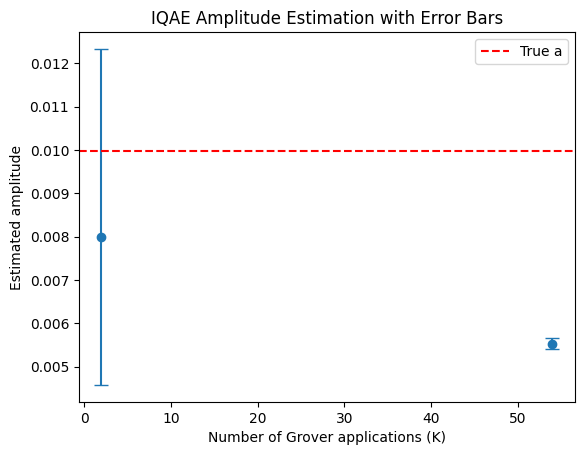

In [ ]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer.primitives import SamplerV2
from scipy.stats import beta
import matplotlib.pyplot as plt

# -------------------------------
# Oracle / Amplitude operator setup
# -------------------------------
def build_A(theta):
    qc = QuantumCircuit(1)
    qc.ry(2 * theta, 0)
    return qc

def build_Q(theta):
    """Grover operator Q = A S0 A_inv S_chi"""
    qc = QuantumCircuit(1)
    qc.z(0)           # Reflection about |1>
    qc.ry(-2*theta,0) # A_inv
    qc.z(0)           # Reflection about |0>
    qc.ry(2*theta,0)  # A
    return qc

# -------------------------------
# Run k Grover iterations and measure
# -------------------------------
def run_k(theta, k, shots=2000):
    qc = QuantumCircuit(1,1)
    qc.ry(2 * theta, 0)
    for _ in range(k):
        Q = build_Q(theta)
        for instr in Q.data:
            qc.append(instr.operation, instr.qubits, instr.clbits)
    qc.measure_all()

    sampler = SamplerV2()
    job = sampler.run([qc], shots=shots)
    result = job.result()
    counts = result[0].data.meas.get_counts()
    p = counts.get('1',0)/shots
    return p

# -------------------------------
# Find next k according to IQAE
# -------------------------------
def find_next_k(ki, theta_l, theta_u, up_i, r=2):
    Ki = 4*ki + 2
    theta_min = Ki * theta_l
    theta_max = Ki * theta_u
    Kmax = int(np.floor(np.pi / (theta_u - theta_l)))
    K = Kmax - (Kmax - 2) % 4

    while K >= r*Ki:
        q = K / Ki
        t_min_mod = (q*theta_min) % (2*np.pi)
        t_max_mod = (q*theta_max) % (2*np.pi)
        # Upper half-plane
        if t_min_mod <= np.pi and t_max_mod <= np.pi:
            ki1 = (K - 2)//4
            return ki1, True
        # Lower half-plane
        if t_min_mod >= np.pi and t_max_mod >= np.pi:
            ki1 = (K - 2)//4
            return ki1, False
        K -= 4
    return ki, up_i

# -------------------------------
# IQAE main function with error tracking
# -------------------------------
def iqae(theta, eps=0.01, alpha=0.05, Nshots=2000, ci="Clopper-Pearson"):
    theta_l, theta_u = 0.0, np.pi/2
    ki = 0
    up_i = True
    iteration = 0

    k_list = []
    a_est_list = []
    a_err_low = []
    a_err_high = []

    print(f"{'i':>3} | {'k':>3} | {'p_meas':>8} | Theta Interval")
    print("-"*50)

    while (theta_u - theta_l) > eps:
        iteration += 1
        ki, up_i = find_next_k(ki, theta_l, theta_u, up_i)
        K = 4*ki + 2

        p_meas = run_k(theta, ki, shots=Nshots)

        # Compute confidence interval
        if ci == "Clopper-Pearson":
            a_min = beta.ppf(alpha/2, Nshots*p_meas + 1, Nshots*(1-p_meas) + 1)
            a_max = beta.ppf(1 - alpha/2, Nshots*p_meas + 1, Nshots*(1-p_meas) + 1)
        else:
            delta = np.sqrt(np.log(2/alpha)/(2*Nshots))
            a_min = max(0, p_meas - delta)
            a_max = min(1, p_meas + delta)

        # Invert to theta
        def theta_bounds(a, K, up):
            cos_val = 1 - 2*a
            cos_val = np.clip(cos_val, -1,1)
            th = np.arccos(cos_val)/K
            if not up:
                th = np.pi/K + th
            return th

        theta_min_i = theta_bounds(a_min, K, up_i)
        theta_max_i = theta_bounds(a_max, K, up_i)

        theta_l = max(theta_l, theta_min_i)
        theta_u = min(theta_u, theta_max_i)
        theta_u = max(theta_l, theta_u)  # prevents flipping

        a_est_i = np.sin((theta_l + theta_u)/2)**2

        # Store for plotting
        k_list.append(K)
        a_est_list.append(a_est_i)
        a_err_low.append(a_est_i - np.sin(theta_l)**2)
        a_err_high.append(np.sin(theta_u)**2 - a_est_i)

        print(f"{iteration:3d} | {ki:3d} | {p_meas:8.4f} | [{theta_l:.4f}, {theta_u:.4f}]")

    # Final estimate
    a_est = np.sin((theta_l + theta_u)/2)**2
    return a_est, k_list, a_est_list, a_err_low, a_err_high

# -------------------------------
# Run IQAE and plot error bars
# -------------------------------
theta_true = 0.1       # Example amplitude rotation
a_true = np.sin(theta_true)**2
shots = 2000

a_est, k_list, a_est_list, err_low, err_high = iqae(theta_true, eps=0.005, alpha=0.05, Nshots=shots)

print(f"\nEstimated a: {a_est:.6f}")
print(f"True a:      {a_true:.6f}")

# Plot error bars
plt.errorbar(k_list, a_est_list, yerr=[err_low, err_high], fmt='o', capsize=5)
plt.axhline(a_true, color='r', linestyle='--', label="True a")
plt.xlabel("Number of Grover applications (K)")
plt.ylabel("Estimated amplitude")
plt.title("IQAE Amplitude Estimation with Error Bars")
plt.legend()
plt.show()


$\mathcal{Q} = \mathcal{A}\mathcal{S}_0\mathcal{A}^\dagger\mathcal{S}_{\Psi_1}$

# Below here is code I tried implementing from the algorithm

It looks almost right but I can't figure out how to make it run enough oracle calls to plot it to show the $\frac{1}{\sqrt{M}}$ relationship.

$\sqrt{1-p} |0\rangle + \sqrt{p} |1\rangle$

In [ ]:
class BernoulliA(QuantumCircuit):

    def __init__(self, probability):
        super().__init__(1)  # creates a circuit with 1 qubit

        theta_p = 2 * np.arcsin(np.sqrt(probability))
        self.ry(theta_p, 0)


In [ ]:
class BernoulliQ(QuantumCircuit):
    """A circuit representing the Bernoulli Q operator."""

    def __init__(self, probability):
        super().__init__(1)  # circuit on 1 qubit

        self._theta_p = 2 * np.arcsin(np.sqrt(probability))
        self.ry(2 * self._theta_p, 0)

    def power(self, k):
        # implement the efficient power of Q
        q_k = QuantumCircuit(1)
        q_k.ry(2 * k * self._theta_p, 0)
        return q_k


In [ ]:
p=0.35
A = BernoulliA(p)
Q = BernoulliQ(p)


Code to actually run the simulation

In [ ]:

problem = EstimationProblem(
    state_preparation=A,  # A operator
    grover_operator=Q,  # Q operator
    objective_qubits=[0],  # the "good" state Psi1 is identified as measuring |1> in qubit 0
)
sampler = SamplerV2()

iae = IterativeAmplitudeEstimation(
    epsilon_target=0.01,  # target accuracy
    alpha=0.05,  # width of the confidence interval
    sampler=sampler,
)
iae_result = iae.estimate(problem)
exact_oracle_calls = result.num_oracle_queries
print(f"Exact oracle calls: {exact_oracle_calls}")
print("Estimate:", iae_result.estimation)

AttributeError: Attribute num_oracle_queries is not defined